# Mini Projeto 03
### Análise Estatística de Dados com NumPy Para a Área de Marketing
---

## 1. Definição do Problema de Negócio

### 1.1. Contexto

Uma plataforma de e-commerce coleta um volume significativo de dados sobre a interação dos usuários com o site, incluindo o número de visitas, a duração da sessão, a atividade de adição de produtos ao carrinho e os valores de compra finalizados. No entanto, esses dados estão sendo subutilizados. Atualmente, as decisões sobre campanhas de marketing, promoções e melhorias na experiência do usuário (UX) são tomadas com base em intuição e métricas de alto nível, sem uma compreensão aprofundada dos padrões de comportamento que impulsionam os resultados.

### 1.2. Problema de Negócio

A empresa enfrenta o desafio de compreender profundamente os padrões de comportamento que diferenciam os clientes de alto valor dos visitantes que abandonam o site sem comprar. Essa falta de clareza resulta em:

- Marketing Genérico: Nossas campanhas de marketing são de "tamanho único", resultando em baixo engajamento e desperdício de orçamento, pois não conseguimos personalizar as ofertas para os segmentos de clientes corretos.

- Perda de Oportunidades: Não conseguimos identificar e engajar proativamente os clientes com maior potencial de compra ou criar estratégias para converter os visitantes que demonstram interesse, mas não finalizam a compra.

- Decisões Não Embasadas: As estratégias de produto e de experiência do usuário carecem de uma base quantitativa sólida sobre quais comportamentos (ex: tempo no site, frequência de visitas) estão mais fortemente correlacionados com o sucesso das vendas.

### 1.3. Objetivo Principal

Utilizar a análise estatística dos dados de navegação e compra para segmentar clientes, identificar os principais indicadores de comportamento que levam à conversão e fornecer insights acionáveis para as equipes de marketing e produto, a fim de aumentar o ticket médio e a taxa de conversão geral da plataforma.

### 1.4. Perguntas-Chave a Serem Respondidas

A análise de dados deve responder às seguintes perguntas críticas de negócio:

- 1- Qual é o perfil médio do nosso usuário em termos de visitas, tempo de navegação e valor de compra (ticket médio)?

- 2- Quais são as características e comportamentos distintos dos nossos clientes de "Alto Valor"? Eles visitam mais o site? Passam mais tempo navegando?

- 3- Qual é o comportamento dos usuários que visitam o site, mas não realizam nenhuma compra? Onde está a oportunidade de conversão com este grupo?

- 4- Existe uma correlação estatisticamente relevante entre o tempo gasto no site, o número de itens no carrinho e o valor final da compra?

### 1.5. Resultado Esperado e Impacto no Negócio

O resultado deste projeto será um relatório de análise estatística que permitirá:

- Segmentação Aprimorada: Criação de pelo menos dois segmentos de clientes (ex: "Clientes de Alto Valor" e "Visitantes Engajados sem Compra") para direcionamento de campanhas de marketing personalizadas.

- Otimização de Marketing: Direcionar o orçamento de marketing para ações focadas nos comportamentos que mais se correlacionam com compras de alto valor, aumentando o Retorno Sobre o Investimento (ROI).

- Melhoria da Experiência do Usuário (UX): Fornecer à equipe de produto dados que possam justificar testes A/B ou melhorias em áreas do site frequentadas por usuários que não convertem.

---
## 2 - Importação das Bibliotecas

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# definicao de uma semente para reprodutibilidade dos dados randomicos
np.random.seed(42)

In [6]:
%reload_ext watermark
%watermark -a "mvbr"

Author: mvbr



In [7]:
%watermark --iversions

matplotlib: 3.10.9
numpy     : 2.4.4
pandas    : 3.0.2
seaborn   : 0.13.2



---
## 3 - Etapa para Geração de Dados Fictícios

Vamos criar um conjunto de dados para 500 usuários. Cada usuário terá 4 métricas associadas descritas abaixo.

- visitas: Número de vezes que o usuário visitou o site no mês.

- tempo_no_site: Tempo total em minutos que o usuário passou no site.

- itens_no_carrinho: Número de itens que o usuário adicionou ao carrinho.

- valor_compra: O valor total em R$ da compra realizada pelo usuário no mês.

In [11]:
# definicao do numero de usuarios
quantidade_usuarios = 500

In [12]:
# definicao da quantidade de visitas (entre 1 e 50)
quantidade_visitas = np.random.randint(1, 51, size = quantidade_usuarios)

A distribuição normal é um tipo de distribuição de probabilidade contínua, simétrica em torno da média, com formato característico de sino. Nesse tipo de distribuição os valores próximos da média são mais frequentes e a probabilidade de observar valores extremos diminui gradualmente conforme se afastam do centro. É definida por dois parâmetros: a média (que indica o centro da distribuição) e o desvio padrão (que indica a dispersão dos dados). É muito usada em Estatística e Ciência de Dados porque muitos fenômenos naturais e sociais tendem a seguir esse padrão.

In [16]:
# definicao do tempo no site (distribuicao normal, correlacionado com a quantidade de visitas)
# media de 20 minutos, devio padrao de 5, com um bonus por quantidade de visitas
tempo_no_site = np.random.normal(loc = 20, scale = 5, size = quantidade_usuarios) + (quantidade_visitas * 0.5)
tempo_no_site = np.round(tempo_no_site, 2)

In [19]:
# definicao da quantidade de itens no carrinho (dependente da quantidade de visitas e tempo no site)
# usuarios que visitam mais e passam mais tempo, tendem a adicionar mais itens
quantidade_item_no_carrinho = np.random.randint(0, 8, size = quantidade_usuarios) + quantidade_visitas // 10

In [20]:
# garante que o tempo no site tambem influencie positivamente
quantidade_item_no_carrinho = (quantidade_item_no_carrinho + (tempo_no_site // 15)).astype(np.int32)

In [21]:
# definicao do valor da compra (correlacionado com os itens no carrinho)
valor_compra = (quantidade_item_no_carrinho * 35) + np.random.normal(loc = 0, scale = 10, size = quantidade_usuarios)

In [22]:
type(valor_compra)

numpy.ndarray

In [23]:
type(quantidade_item_no_carrinho)

numpy.ndarray

In [24]:
# se nao houver itens no carrinho, o valor da compra deve ser 0
valor_compra[quantidade_item_no_carrinho == 0] = 0
valor_compra[valor_compra < 0] = 0 # corrige possiveis valores negativos
valor_compra = np.round(valor_compra, 2)

In [26]:
# unindo tudo em uma unica matriz (ndarray)
# cada linha representa um usuario, cada coluna representa uma metrica
dados_ecommerce = np.column_stack((quantidade_visitas, tempo_no_site, quantidade_item_no_carrinho, valor_compra))

In [29]:
print("\nShape da nossa massa de dados:", dados_ecommerce.shape)
print("\nExemplo dos 5 primeiros usuários (linhas):")
print("\nColunas: [Visitas, Tempo no Site (min), Itens no Carrinho, Valor da Compra (R$)]\n")
print(dados_ecommerce[:5])


Shape da nossa massa de dados: (500, 4)

Exemplo dos 5 primeiros usuários (linhas):

Colunas: [Visitas, Tempo no Site (min), Itens no Carrinho, Valor da Compra (R$)]

[[ 48.    43.32  11.   393.23]
 [ 21.    35.95  11.   374.5 ]
 [ 39.    40.6   12.   429.58]
 [ 36.    44.45   7.   225.34]
 [ 33.    38.63   8.   304.29]]


---
## 4. Análise Estatística Descritiva

Agora que temos os dados, vamos calcular as principais métricas estatísticas para cada coluna para ter uma visão geral do comportamento dos nossos usuários.

- A média é a soma de todos os valores dividida pela quantidade de elementos. Ela indica o valor “central” ou típico de um conjunto de dados.

- A mediana é o valor que fica exatamente no meio quando os dados estão ordenados. Se houver um número par de valores, é a média dos dois valores centrais. Ela é menos sensível a valores muito extremos do que a média.

- O desvio padrão mede o quanto os valores se afastam, em média, da média do conjunto. Um desvio padrão alto significa que os dados são mais espalhados; um baixo indica que estão mais próximos da média.

### Pergunta 1

Qual é o perfil médio do nosso usuário em termos de visitas, tempo de navegação e valor de compra (ticket médio)?

In [30]:
# Separando as colunas para facilitar a leitura do código
visitas_col = dados_ecommerce[:, 0]
tempo_col   = dados_ecommerce[:, 1]
itens_col   = dados_ecommerce[:, 2]
valor_col   = dados_ecommerce[:, 3]

print("--- ANÁLISE ESTATÍSTICA GERAL ---")

# Média
media_visitas = np.mean(visitas_col)
media_tempo   = np.mean(tempo_col)
media_itens   = np.mean(itens_col)
media_valor   = np.mean(valor_col)

print(f"\nMédia de Visitas: {media_visitas:.2f}")
print(f"Média de Tempo no Site: {media_tempo:.2f} min")
print(f"Média de Itens no Carrinho: {media_itens:.2f}")
print(f"Média de Valor de Compra (Ticket Médio): R$ {media_valor:.2f}")

# Mediana (valor central, menos sensível a outliers)
mediana_valor = np.median(valor_col)
print(f"\nMediana do Valor de Compra: R$ {mediana_valor:.2f}")

# Desvio Padrão (mede a dispersão dos dados)
std_valor = np.std(valor_col)
print(f"Desvio Padrão do Valor de Compra: R$ {std_valor:.2f}")

# Valores Máximos e Mínimos
max_valor = np.max(valor_col)
min_valor_positivo = np.min(valor_col[valor_col > 0]) # Mínimo apenas entre quem comprou
print(f"Maior Valor de Compra: R$ {max_valor:.2f}")
print(f"Menor Valor de Compra (de quem comprou): R$ {min_valor_positivo:.2f}")

--- ANÁLISE ESTATÍSTICA GERAL ---

Média de Visitas: 25.80
Média de Tempo no Site: 33.09 min
Média de Itens no Carrinho: 7.43
Média de Valor de Compra (Ticket Médio): R$ 259.62

Mediana do Valor de Compra: R$ 252.11
Desvio Padrão do Valor de Compra: R$ 102.99
Maior Valor de Compra: R$ 517.04
Menor Valor de Compra (de quem comprou): R$ 18.37


Este gráfico abaixo mostra o histograma dos valores de compra com linhas verticais indicando a média (vermelho), a mediana (laranja) e o intervalo de um desvio padrão acima e abaixo da média (linhas verdes). Isso facilita a análise de como os dados estão distribuídos e se existem possíveis outliers ou assimetrias.

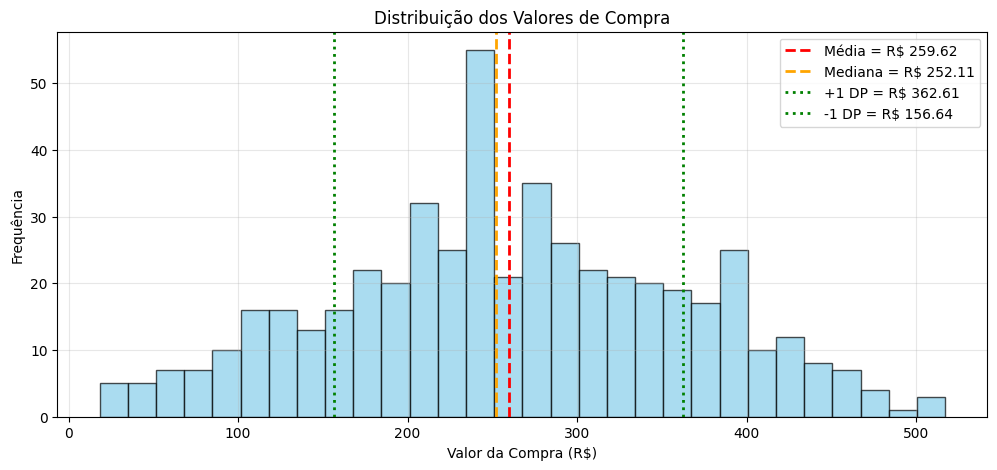

In [32]:
# Separando colunas
visitas_col = dados_ecommerce[:, 0]
tempo_col   = dados_ecommerce[:, 1]
itens_col   = dados_ecommerce[:, 2]
valor_col   = dados_ecommerce[:, 3]

# Calculando as Estatísticas
media_valor = np.mean(valor_col)
mediana_valor = np.median(valor_col)
std_valor = np.std(valor_col)

# --- GRÁFICO ---
plt.figure(figsize = (12, 5))
plt.hist(valor_col, bins = 30, color = 'skyblue', edgecolor = 'black', alpha = 0.7)
plt.axvline(media_valor, color = 'red', linestyle = '--', linewidth = 2, label = f'Média = R$ {media_valor:.2f}')
plt.axvline(mediana_valor, color = 'orange', linestyle = '--', linewidth = 2, label = f'Mediana = R$ {mediana_valor:.2f}')
plt.axvline(media_valor + std_valor, color = 'green', linestyle = ':', linewidth = 2, label = f'+1 DP = R$ {media_valor + std_valor:.2f}')
plt.axvline(media_valor - std_valor, color = 'green', linestyle = ':', linewidth = 2, label = f'-1 DP = R$ {media_valor - std_valor:.2f}')
plt.title('Distribuição dos Valores de Compra')
plt.xlabel('Valor da Compra (R$)')
plt.ylabel('Frequência')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

**Resposta da Pergunta 1:**

O usuário acessa o site, em média, cerca de 26 vezes por mês, permanece em média 33 minutos navegando, adiciona aproximadamente 7 itens ao carrinho e realiza compras com ticket médio de R$ 259.62. 

O gasto típico fica próximo da mediana de R$ 252,11.

Mas há grande variação entre clientes, alguns compram valores baixos a partir de R$ 18.37. 

Enquanto outros chegam a gastar até R$ 517.04.

---
## 5. Segmentação e Análise de Clientes

Vamos usar a indexação booleana para filtrar e analisar segmentos específicos de clientes.

### Pergunta 2

Quais são as características e comportamentos distintos dos nossos clientes de "Alto Valor"? Eles visitam mais o site? Passam mais tempo navegando?

In [33]:
# Filtro booleano para clientes com compras > R$ 250
clientes_alto_valor = dados_ecommerce[dados_ecommerce[:, 3] > 250]

print("\n--- ANÁLISE: CLIENTES DE ALTO VALOR (Compras > R$ 250) ---\n")
print(f"Número de clientes de alto valor: {clientes_alto_valor.shape[0]}")

# Estatísticas deste segmento
media_visitas_alto_valor = np.mean(clientes_alto_valor[:, 0])
media_tempo_alto_valor = np.mean(clientes_alto_valor[:, 1])

print(f"Média de visitas desses clientes: {media_visitas_alto_valor:.2f}")
print(f"Média de tempo no site desses clientes: {media_tempo_alto_valor:.2f} min")


--- ANÁLISE: CLIENTES DE ALTO VALOR (Compras > R$ 250) ---

Número de clientes de alto valor: 253
Média de visitas desses clientes: 30.87
Média de tempo no site desses clientes: 35.62 min


**Resposta da Pergunta 2:**

Os clientes de alto valor (aqueles que gastam mais de R$ 250) visitam o site com maior frequência, em média 30 vezes por mês, e permanecem mais tempo navegando, cerca de 35 minutos por sessão. Esse comportamento indica um alto nível de engajamento, sugerindo que quanto mais esses usuários interagem com a plataforma, maior tende a ser o valor de suas compras.

### Pergunta 3

Qual é o comportamento dos usuários que visitam o site, mas não realizam nenhuma compra? Onde está a oportunidade de conversão com este grupo?